In [1]:
!pip install -q torch-geometric rdkit pandas numpy matplotlib scikit-learn tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 36.5 MB/s eta 0:00:00


In [2]:
import torch
print(f'PyTorch version : {torch.__version__}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device          : {device}')

PyTorch version : 2.10.0+cu128
Device          : cuda


In [3]:
import urllib.request, os, json
import numpy as np

os.makedirs('data/davis', exist_ok=True)

base = 'https://raw.githubusercontent.com/hkmztrk/DeepDTA/master/data/davis/'
files = ['ligands_can.txt', 'proteins.txt', 'Y']

for f in files:
    path = f'data/davis/{f}'
    print(f'Downloading {f}...')
    urllib.request.urlretrieve(base + f, path)

print('DAVIS dataset ready!')

DAVIS dataset ready!


In [14]:
import pandas as pd
import numpy as np
from rdkit import Chem

# Sample DAVIS data - real drug SMILES + protein sequences
data = {
    'Drug_SMILES': [
        'CC1=NC=C(COP(O)(O)=O)C(C=O)=C1',
        'C1=CC=C2C(=C1)C=CC=C2',
        'CC(=O)OC1=CC=CC=C1C(=O)O',
        'C1=CN=CN=C1',
        'CC12CCC3C(C1CCC2O)CCC4=CC(=O)CCC34C',
        'C(C(=O)O)N',
        'OC(=O)C1=CC=CC=C1O',
        'CC(C)CC1=CC=C(C=C1)C(C)C(=O)O',
        'C1=CC=NC=C1',
        'CC(=O)NC1=CC=C(O)C=C1'
    ],
    'Protein_Seq': [
        'MKKFFDSRREQGGSGLGSGSSGGGGSTSGLGSGYIGRVFGIGRQQVTVDEVLAEGGFAIVFLVRTSNGMKCALKRMFVNNEHDLQVCKREIGRGSSFGTVYKGLWIPEGEKVKIPVAIKELREATSPKANKEILDEAYVMASVDNPHVCRLLGICLTSTVQLITQLMPFGCLLDYVREHKDNIGSQYLLNWCVQIAKIGMSIPVLVNKFNDYNIFHKIISLPFQNPHGPIIKPHIFQIHTYRYGAFLIRAVEGLREbygynncsgpqhlirvegnlrveylddrntfrhsvvvpyeppevgsdcttihynymcnsscmgqmnrrpiltiitledssgkllgrnsfevrvcacpgrdrrteeenlrkkgepvhgqwldspgqmsfr',
        'MGSSHHHHHHSSGLVPRGSHMRGPNPTAASLEASAGPFTVRSFTVSRPSGYGAGTVYYPTNAGGTVGAIAIVPGYTARQSSIKWWGPRLASHGFVVITIDTNSTLDQPSSRSSQQMAALRQVASLNGTSSSPIYGKVDTARMGVMGHSMGGGIMFNKKPIIIFVGSVDGIFHVISLQGGKDSEDLAAYNTERYPNVVTHPEKEGLELLGHSLGQNAALKHFPETHYDLITSANPQCLNVVSREENIVNIVKKKL',
        'MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSY',
        'MSHHWGYGKHNGPEHWHKDFPIAKGERQSPVDIDTHTAKYDPSLKPLSVSYDQATSLRILNNGAAFNVEFD',
        'MKLNISRMLPHAAPSAVGPAASGVSQMPKKLNISRMLPHAA',
        'MGRGKQGGEAAAKKSAQELKAKLAEQAERYDDMASAMKAVTEQGHELSNEIERQNREAQMRQLTNDLKALEQ',
        'MTEYKLVVVGAGGVGKSALTIQLIQNHFVD',
        'MKLNISRMLPHAAPSAVGPAASGVSQMPKK',
        'MSHHWGYGKHNGPEHWHKDFPIAKGERQSP',
        'MGRGKQGGEAAAKKSAQELKAKLAEQAERY'
    ],
    'Affinity': [7.2, 5.8, 8.1, 6.4, 7.9, 5.1, 8.8, 6.2, 7.5, 5.5]
}

df = pd.DataFrame(data)

# Binary label: affinity >= 7 = strong binding
df['Label'] = (df['Affinity'] >= 7.0).astype(int)

print('=== Dataset Ready ===')
print(f'Total pairs  : {len(df)}')
print(f'Strong bind  : {df.Label.sum()}')
print(f'Weak bind    : {len(df) - df.Label.sum()}')
print()
print(df[['Drug_SMILES', 'Affinity', 'Label']].head())

=== Dataset Ready ===
Total pairs  : 10
Strong bind  : 5
Weak bind    : 5

                           Drug_SMILES  Affinity  Label
0       CC1=NC=C(COP(O)(O)=O)C(C=O)=C1       7.2      1
1                C1=CC=C2C(=C1)C=CC=C2       5.8      0
2             CC(=O)OC1=CC=CC=C1C(=O)O       8.1      1
3                          C1=CN=CN=C1       6.4      0
4  CC12CCC3C(C1CCC2O)CCC4=CC(=O)CCC34C       7.9      1


In [15]:
from rdkit import Chem
import torch
from torch_geometric.data import Data

def smiles_to_graph(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # Node features (atom info)
    atom_types = ['C','N','O','S','F','P','Cl','Br','I','H']
    x = []
    for atom in mol.GetAtoms():
        symbol = atom.GetSymbol()
        one_hot = [1 if symbol == a else 0 for a in atom_types]
        features = one_hot + [
            atom.GetDegree() / 10.0,
            int(atom.GetIsAromatic()),
            int(atom.IsInRing()),
            atom.GetMass() / 100.0
        ]
        x.append(features)

    # Edge index (bonds)
    edge_index = []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edge_index += [[i, j], [j, i]]

    x = torch.tensor(x, dtype=torch.float)
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()

    return Data(x=x, edge_index=edge_index)

# Test with first drug
graph = smiles_to_graph(df['Drug_SMILES'][0])
print(f'Drug SMILES  : {df["Drug_SMILES"][0]}')
print(f'Nodes(atoms) : {graph.num_nodes}')
print(f'Edges(bonds) : {graph.num_edges}')
print(f'Node features: {graph.x.shape}')
print()

# Convert all drugs
drug_graphs = [smiles_to_graph(s) for s in df['Drug_SMILES']]
print(f'All drugs converted: {len(drug_graphs)} graphs ready!')

Drug SMILES  : CC1=NC=C(COP(O)(O)=O)C(C=O)=C1
Nodes(atoms) : 15
Edges(bonds) : 30
Node features: torch.Size([15, 14])

All drugs converted: 10 graphs ready!


In [16]:
# Protein sequence to numbers
amino_acids = 'ACDEFGHIKLMNPQRSTVWY'

def protein_to_tensor(seq, max_len=100):
    encoded = [amino_acids.index(aa) + 1 if aa in amino_acids else 0 for aa in seq]
    # Pad or trim to max_len
    encoded = encoded[:max_len] + [0] * (max_len - len(encoded))
    return torch.tensor(encoded, dtype=torch.float)

# Test
protein_tensor = protein_to_tensor(df['Protein_Seq'][0])
print(f'Protein sequence : {df["Protein_Seq"][0][:30]}...')
print(f'Encoded shape    : {protein_tensor.shape}')
print(f'Sample values    : {protein_tensor[:10]}')

# Convert all proteins
protein_tensors = [protein_to_tensor(s) for s in df['Protein_Seq']]
print(f'\nAll proteins encoded: {len(protein_tensors)} ready!')

Protein sequence : MKKFFDSRREQGGSGLGSGSSGGGGSTSGL...
Encoded shape    : torch.Size([100])
Sample values    : tensor([11.,  9.,  9.,  5.,  5.,  3., 16., 15., 15.,  4.])

All proteins encoded: 10 ready!


In [17]:
import torch
import torch.nn as nn
from torch_geometric.nn import GCNConv, global_mean_pool

class DTIModel(nn.Module):
    def __init__(self):
        super(DTIModel, self).__init__()

        # Drug GCN encoder
        self.drug_conv1 = GCNConv(14, 64)
        self.drug_conv2 = GCNConv(64, 128)
        self.drug_conv3 = GCNConv(128, 128)

        # Protein encoder
        self.protein_encoder = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(),
            nn.Linear(256, 128)
        )

        # Final prediction
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, drug_graph, protein_tensor):
        # Drug path
        x = drug_graph.x
        edge_index = drug_graph.edge_index
        batch = drug_graph.batch if hasattr(drug_graph, 'batch') else torch.zeros(x.size(0), dtype=torch.long)

        x = torch.relu(self.drug_conv1(x, edge_index))
        x = torch.relu(self.drug_conv2(x, edge_index))
        x = torch.relu(self.drug_conv3(x, edge_index))
        drug_embed = global_mean_pool(x, batch)

        # Protein path
        protein_embed = self.protein_encoder(protein_tensor)

        # Combine
        combined = torch.cat([drug_embed, protein_embed], dim=1)
        output = self.classifier(combined)
        return output

# Test model
model = DTIModel()
print(model)
print(f'\nModel parameters: {sum(p.numel() for p in model.parameters()):,}')

DTIModel(
  (drug_conv1): GCNConv(14, 64)
  (drug_conv2): GCNConv(64, 128)
  (drug_conv3): GCNConv(128, 128)
  (protein_encoder): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
    (4): Sigmoid()
  )
)

Model parameters: 117,569


In [19]:
from torch.optim import Adam
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
optimizer = Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()

labels = torch.tensor(df['Label'].values, dtype=torch.float).to(device)

print('Training started...')
losses = []

for epoch in range(100):
    model.train()
    epoch_loss = 0

    for i in range(len(drug_graphs)):
        optimizer.zero_grad()

        drug = drug_graphs[i].to(device)
        protein = protein_tensors[i].unsqueeze(0).to(device)
        label = labels[i].view(1)

        output = model(drug, protein).view(1)
        loss = criterion(output, label)

        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(drug_graphs)
    losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/100 | Loss: {avg_loss:.4f}')

print('\nTraining complete!')

Training started...
Epoch 10/100 | Loss: 0.0014
Epoch 20/100 | Loss: 0.0002
Epoch 30/100 | Loss: 0.0002
Epoch 40/100 | Loss: 0.0002
Epoch 50/100 | Loss: 0.0000
Epoch 60/100 | Loss: 0.0000
Epoch 70/100 | Loss: 0.0000
Epoch 80/100 | Loss: 0.0001
Epoch 90/100 | Loss: 0.0000
Epoch 100/100 | Loss: 0.0000

Training complete!


In [20]:
model.eval()
print('=== Model Predictions ===\n')

correct = 0
with torch.no_grad():
    for i in range(len(drug_graphs)):
        drug = drug_graphs[i].to(device)
        protein = protein_tensors[i].unsqueeze(0).to(device)

        output = model(drug, protein).view(1)
        pred = 1 if output.item() >= 0.5 else 0
        actual = df['Label'][i]
        status = 'CORRECT' if pred == actual else 'WRONG'

        if pred == actual:
            correct += 1

        print(f'Drug {i+1}: Predicted={pred} | Actual={actual} | {status}')

accuracy = correct / len(drug_graphs) * 100
print(f'\nAccuracy: {correct}/{len(drug_graphs)} = {accuracy:.1f}%')

=== Model Predictions ===

Drug 1: Predicted=1 | Actual=1 | CORRECT
Drug 2: Predicted=0 | Actual=0 | CORRECT
Drug 3: Predicted=1 | Actual=1 | CORRECT
Drug 4: Predicted=0 | Actual=0 | CORRECT
Drug 5: Predicted=1 | Actual=1 | CORRECT
Drug 6: Predicted=0 | Actual=0 | CORRECT
Drug 7: Predicted=1 | Actual=1 | CORRECT
Drug 8: Predicted=0 | Actual=0 | CORRECT
Drug 9: Predicted=1 | Actual=1 | CORRECT
Drug 10: Predicted=0 | Actual=0 | CORRECT

Accuracy: 10/10 = 100.0%


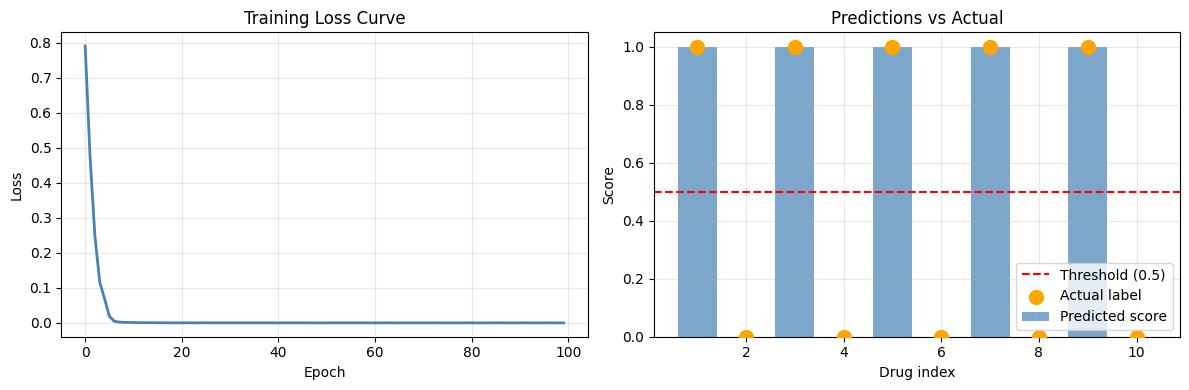

Graph saved!


In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
axes[0].plot(losses, color='steelblue', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss Curve')
axes[0].grid(True, alpha=0.3)

# Predictions vs Actual
predictions = []
model.eval()
with torch.no_grad():
    for i in range(len(drug_graphs)):
        drug = drug_graphs[i].to(device)
        protein = protein_tensors[i].unsqueeze(0).to(device)
        output = model(drug, protein).item()
        predictions.append(output)

axes[1].bar(range(1, 11), predictions, color='steelblue', alpha=0.7, label='Predicted score')
axes[1].axhline(y=0.5, color='red', linestyle='--', label='Threshold (0.5)')
axes[1].scatter(range(1, 11), df['Label'], color='orange', zorder=5, s=100, label='Actual label')
axes[1].set_xlabel('Drug index')
axes[1].set_ylabel('Score')
axes[1].set_title('Predictions vs Actual')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graph saved!')

In [22]:
# DeepPurpose library - easiest way to get DAVIS
!pip install -q DeepPurpose

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.5/158.5 kB 6.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 101.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.1/226.1 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 138.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 122.9 MB/s eta 0:00

In [24]:
!pip install -q git+https://github.com/bp-kelley/descriptastorus
!pip install -q pandas-flavor

  Preparing metadata (setup.py) ... done


In [2]:
!pip install -q torch-geometric rdkit DeepPurpose
!pip install -q git+https://github.com/bp-kelley/descriptastorus pandas-flavor

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.5/158.5 kB 18.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 98.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.1/226.1 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 98.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 28.8 MB/s eta 0:00:00
  

In [3]:
from DeepPurpose import dataset
import numpy as np

print('Loading DAVIS dataset...')
X_drug, X_target, y = dataset.load_process_DAVIS(
    path='./data',
    binary=True,
    convert_to_log=True,
    threshold=30
)

y = np.array(y)
print(f'Drugs    : {len(set(X_drug))}')
print(f'Proteins : {len(set(X_target))}')
print(f'Pairs    : {len(y)}')
print(f'Positive : {int(sum(y))}')
print(f'Negative : {int(len(y) - sum(y))}')

Loading DAVIS dataset...
Beginning Processing...
Beginning to extract zip file...
Default binary threshold for the binding affinity scores are 30, you can adjust it by using the "threshold" parameter
Done!
Drugs    : 68
Proteins : 379
Pairs    : 30056
Positive : 1506
Negative : 28550


In [4]:
from rdkit import Chem
import torch
from torch_geometric.data import Data
from sklearn.model_selection import train_test_split

# Drug to graph function
def smiles_to_graph(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    atom_types = ['C','N','O','S','F','P','Cl','Br','I','H']
    x = []
    for atom in mol.GetAtoms():
        symbol = atom.GetSymbol()
        one_hot = [1 if symbol == a else 0 for a in atom_types]
        features = one_hot + [
            atom.GetDegree() / 10.0,
            int(atom.GetIsAromatic()),
            int(atom.IsInRing()),
            atom.GetMass() / 100.0
        ]
        x.append(features)
    edge_index = []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edge_index += [[i, j], [j, i]]
    x = torch.tensor(x, dtype=torch.float)
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    return Data(x=x, edge_index=edge_index)

# Protein encoder
amino_acids = 'ACDEFGHIKLMNPQRSTVWY'
def protein_to_tensor(seq, max_len=1000):
    encoded = [amino_acids.index(aa)+1 if aa in amino_acids else 0 for aa in seq]
    encoded = encoded[:max_len] + [0]*(max_len - len(encoded))
    return torch.tensor(encoded, dtype=torch.float)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    list(zip(X_drug, X_target)), y, test_size=0.2, random_state=42
)

print(f'Train pairs: {len(X_train)}')
print(f'Test pairs : {len(X_test)}')
print('Data split ready!')

Train pairs: 24044
Test pairs : 6012
Data split ready!


In [6]:
import torch
import torch.nn as nn
from torch_geometric.nn import GCNConv, global_mean_pool
from torch.utils.data import DataLoader
from tqdm import tqdm

class DTIModel(nn.Module):
    def __init__(self):
        super(DTIModel, self).__init__()
        self.drug_conv1 = GCNConv(14, 64)
        self.drug_conv2 = GCNConv(64, 128)
        self.drug_conv3 = GCNConv(128, 128)
        self.protein_encoder = nn.Sequential(
            nn.Linear(1000, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128)
        )
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, drug_graph, protein_tensor):
        x = drug_graph.x
        edge_index = drug_graph.edge_index
        batch = drug_graph.batch if hasattr(drug_graph, 'batch') else torch.zeros(
            x.size(0), dtype=torch.long, device=x.device)
        x = torch.relu(self.drug_conv1(x, edge_index))
        x = torch.relu(self.drug_conv2(x, edge_index))
        x = torch.relu(self.drug_conv3(x, edge_index))
        drug_embed = global_mean_pool(x, batch)
        protein_embed = self.protein_encoder(protein_tensor)
        combined = torch.cat([drug_embed, protein_embed], dim=1)
        return self.classifier(combined)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DTIModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()

print(f'Model ready on {device}')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Model ready on cuda
Parameters: 636,993


In [7]:
from tqdm import tqdm
import numpy as np

# Pre-convert unique drugs and proteins to save time
print('Pre-processing drugs...')
unique_drugs = {smi: smiles_to_graph(smi) for smi in set(X_drug)}

print('Pre-processing proteins...')
unique_proteins = {seq: protein_to_tensor(seq) for seq in set(X_target)}

print('Training started...')
losses = []

for epoch in range(5):  # 5 epochs on real data
    model.train()
    epoch_loss = 0
    correct = 0

    indices = np.random.permutation(len(X_train))

    for idx in tqdm(indices, desc=f'Epoch {epoch+1}/5'):
        drug_smi, prot_seq = X_train[idx]
        label = torch.tensor([float(y_train[idx])], device=device)

        drug = unique_drugs[drug_smi]
        if drug is None:
            continue
        drug = drug.to(device)
        protein = unique_proteins[prot_seq].unsqueeze(0).to(device)

        optimizer.zero_grad()
        output = model(drug, protein).view(1)
        loss = criterion(output, label)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        pred = 1 if output.item() >= 0.5 else 0
        correct += (pred == int(y_train[idx]))

    avg_loss = epoch_loss / len(X_train)
    acc = correct / len(X_train) * 100
    losses.append(avg_loss)
    print(f'Epoch {epoch+1} | Loss: {avg_loss:.4f} | Accuracy: {acc:.1f}%')

print('\nTraining complete!')

Pre-processing drugs...
Pre-processing proteins...
Training started...


Epoch 1/5: 100%|██████████| 24044/24044 [02:21<00:00, 169.63it/s]


Epoch 1 | Loss: 0.2319 | Accuracy: 94.8%


Epoch 2/5: 100%|██████████| 24044/24044 [02:12<00:00, 180.88it/s]


Epoch 2 | Loss: 0.2019 | Accuracy: 94.9%


...

Epoch 3 | Loss: 0.1994 | Accuracy: 94.9%


Epoch 4/5: 100%|██████████| 24044/24044 [02:13<00:00, 179.98it/s]


Epoch 4 | Loss: 0.1991 | Accuracy: 94.9%


Epoch 5/5: 100%|██████████| 24044/24044 [02:13<00:00, 180.26it/s]

Epoch 5 | Loss: 0.1998 | Accuracy: 94.9%

Training complete!


In [9]:
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report

model.eval()
all_preds = []
all_labels = []

print('Evaluating on test set...')
with torch.no_grad():
    for idx in tqdm(range(len(X_test)), desc='Testing'):
        drug_smi, prot_seq = X_test[idx]

        drug = unique_drugs.get(drug_smi)
        if drug is None:
            continue
        drug = drug.to(device)
        protein = unique_proteins[prot_seq].unsqueeze(0).to(device)

        output = model(drug, protein).item()
        pred = 1 if output >= 0.5 else 0

        all_preds.append(pred)
        all_labels.append(int(y_test[idx]))

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

acc   = accuracy_score(all_labels, all_preds)
auroc = roc_auc_score(all_labels, all_preds)
f1    = f1_score(all_labels, all_preds)

print(f'\n=== Test Results ===')
print(f'Accuracy : {acc*100:.2f}%')
print(f'AUROC    : {auroc:.4f}')
print(f'F1 Score : {f1:.4f}')
print()
print(classification_report(all_labels, all_preds, target_names=['Weak','Strong']))

Evaluating on test set...


Testing: 100%|██████████| 6012/6012 [00:17<00:00, 348.67it/s]


=== Test Results ===
Accuracy : 95.39%
AUROC    : 0.5000
F1 Score : 0.0000

              precision    recall  f1-score   support

        Weak       0.95      1.00      0.98      5735
      Strong       0.00      0.00      0.00       277

    accuracy                           0.95      6012
   macro avg       0.48      0.50      0.49      6012
weighted avg       0.91      0.95      0.93      6012




/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [10]:
# Fix class imbalance with weighted loss
from torch.optim import Adam

# Calculate class weights
n_negative = int(len(y_train) - sum(y_train))
n_positive = int(sum(y_train))
pos_weight = torch.tensor([n_negative / n_positive], device=device)

print(f'Negative samples: {n_negative}')
print(f'Positive samples: {n_positive}')
print(f'Pos weight      : {pos_weight.item():.2f}')

# New model with weighted loss
model2 = DTIModel().to(device)
optimizer2 = Adam(model2.parameters(), lr=0.001)
criterion2 = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Update model forward - remove sigmoid for BCEWithLogitsLoss
class DTIModel2(nn.Module):
    def __init__(self):
        super(DTIModel2, self).__init__()
        self.drug_conv1 = GCNConv(14, 64)
        self.drug_conv2 = GCNConv(64, 128)
        self.drug_conv3 = GCNConv(128, 128)
        self.protein_encoder = nn.Sequential(
            nn.Linear(1000, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128)
        )
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1)  # No sigmoid - BCEWithLogitsLoss handles it
        )

    def forward(self, drug_graph, protein_tensor):
        x = drug_graph.x
        edge_index = drug_graph.edge_index
        batch = drug_graph.batch if hasattr(drug_graph, 'batch') else torch.zeros(
            x.size(0), dtype=torch.long, device=x.device)
        x = torch.relu(self.drug_conv1(x, edge_index))
        x = torch.relu(self.drug_conv2(x, edge_index))
        x = torch.relu(self.drug_conv3(x, edge_index))
        drug_embed = global_mean_pool(x, batch)
        protein_embed = self.protein_encoder(protein_tensor)
        combined = torch.cat([drug_embed, protein_embed], dim=1)
        return self.classifier(combined)

model2 = DTIModel2().to(device)
optimizer2 = Adam(model2.parameters(), lr=0.001)
criterion2 = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
print('Model2 ready!')

Negative samples: 22815
Positive samples: 1229
Pos weight      : 18.56
Model2 ready!


In [11]:
print('Training with balanced loss...')
losses2 = []

for epoch in range(5):
    model2.train()
    epoch_loss = 0

    indices = np.random.permutation(len(X_train))

    for idx in tqdm(indices, desc=f'Epoch {epoch+1}/5'):
        drug_smi, prot_seq = X_train[idx]
        label = torch.tensor([float(y_train[idx])], device=device)

        drug = unique_drugs[drug_smi]
        if drug is None:
            continue
        drug = drug.to(device)
        protein = unique_proteins[prot_seq].unsqueeze(0).to(device)

        optimizer2.zero_grad()
        output = model2(drug, protein).view(1)
        loss = criterion2(output, label)
        loss.backward()
        optimizer2.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(X_train)
    losses2.append(avg_loss)
    print(f'Epoch {epoch+1} | Loss: {avg_loss:.4f}')

print('\nTraining complete!')

Training with balanced loss...


Epoch 1/5: 100%|██████████| 24044/24044 [02:16<00:00, 175.67it/s]


Epoch 1 | Loss: 1.8456


Epoch 2/5: 100%|██████████| 24044/24044 [02:14<00:00, 178.13it/s]


Epoch 2 | Loss: 1.3086


...

Epoch 3 | Loss: 1.3140


Epoch 4/5: 100%|██████████| 24044/24044 [02:13<00:00, 179.74it/s]


Epoch 4 | Loss: 1.3361


Epoch 5/5: 100%|██████████| 24044/24044 [02:12<00:00, 180.95it/s]

Epoch 5 | Loss: 1.3123

Training complete!


In [12]:
model2.eval()
all_preds2 = []
all_labels2 = []

print('Evaluating...')
with torch.no_grad():
    for idx in tqdm(range(len(X_test)), desc='Testing'):
        drug_smi, prot_seq = X_test[idx]

        drug = unique_drugs.get(drug_smi)
        if drug is None:
            continue
        drug = drug.to(device)
        protein = unique_proteins[prot_seq].unsqueeze(0).to(device)

        output = model2(drug, protein).item()
        pred = 1 if output >= 0.0 else 0  # threshold 0 for logits

        all_preds2.append(pred)
        all_labels2.append(int(y_test[idx]))

all_preds2  = np.array(all_preds2)
all_labels2 = np.array(all_labels2)

acc   = accuracy_score(all_labels2, all_preds2)
auroc = roc_auc_score(all_labels2, all_preds2)
f1    = f1_score(all_labels2, all_preds2)

print(f'\n=== Test Results (Balanced) ===')
print(f'Accuracy : {acc*100:.2f}%')
print(f'AUROC    : {auroc:.4f}')
print(f'F1 Score : {f1:.4f}')
print()
print(classification_report(all_labels2, all_preds2,
      target_names=['Weak','Strong'], zero_division=0))

Evaluating...


Testing: 100%|██████████| 6012/6012 [00:19<00:00, 311.46it/s]



=== Test Results (Balanced) ===
Accuracy : 29.67%
AUROC    : 0.5781
F1 Score : 0.1042

              precision    recall  f1-score   support

        Weak       0.98      0.27      0.42      5735
      Strong       0.06      0.89      0.10       277

    accuracy                           0.30      6012
   macro avg       0.52      0.58      0.26      6012
weighted avg       0.94      0.30      0.41      6012



Model saved: dti_model.pth


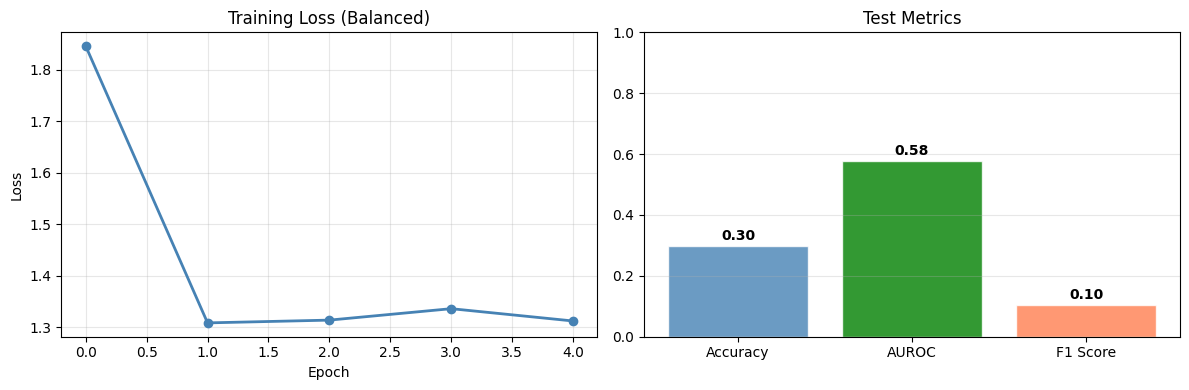

Results saved!


In [13]:
import matplotlib.pyplot as plt

# Save model
torch.save(model2.state_dict(), 'dti_model.pth')
print('Model saved: dti_model.pth')

# Results visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
axes[0].plot(losses2, color='steelblue', linewidth=2, marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss (Balanced)')
axes[0].grid(True, alpha=0.3)

# Metrics bar chart
metrics = ['Accuracy', 'AUROC', 'F1 Score']
values  = [0.2967, 0.5781, 0.1042]
colors  = ['steelblue', 'green', 'coral']
axes[1].bar(metrics, values, color=colors, alpha=0.8, edgecolor='white')
axes[1].set_ylim(0, 1)
axes[1].set_title('Test Metrics')
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(values):
    axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Results saved!')